In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
#Chargement des données
dataF = pd.read_csv('House price.csv', delimiter=',')

In [19]:
#Taille des données
dataF.shape

(4600, 18)

In [20]:
#Features et nombre total de variables
dataF.dtypes.value_counts()

int64      9
object     5
float64    4
Name: count, dtype: int64

In [21]:
#Recherche et suppression des doublons
dataF.drop_duplicates(inplace=True)

In [22]:
#Recherche des valeurs manquantes
msingValue1 = pd.DataFrame(dataF.isna().sum(), columns=['total'])
msingValue2 = pd.DataFrame(dataF.isnull().sum(), columns=['total'])
print("Valeurs manquantes :")
msingValue1[msingValue1['total']>0].sort_values(['total'], ascending=False)
print("Avec isnull :")
msingValue2[msingValue2['total']>0].sort_values(['total'], ascending=False)


Valeurs manquantes :
Avec isnull :


,total


In [23]:
#Description du jeu de données
dataF.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


<Axes: xlabel='price', ylabel='Count'>

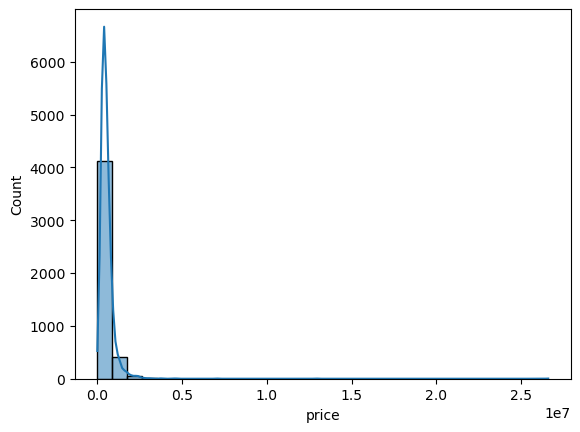

In [24]:
sns.histplot(data=dataF, x='price', bins=30, kde=True)

<Axes: xlabel='sqft_living', ylabel='Count'>

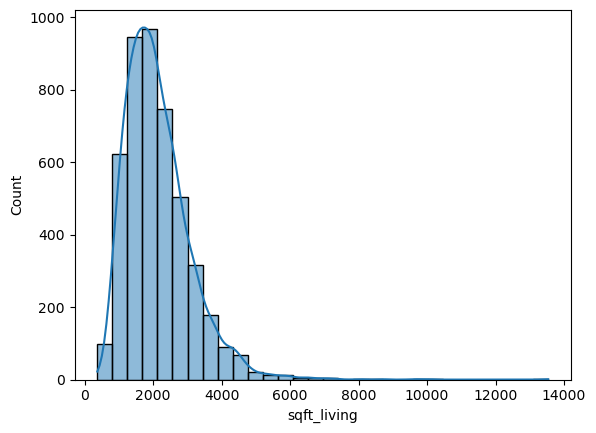

In [25]:
sns.histplot(data=dataF, x='sqft_living', bins=30, kde=True)

<Axes: xlabel='sqft_lot', ylabel='Count'>

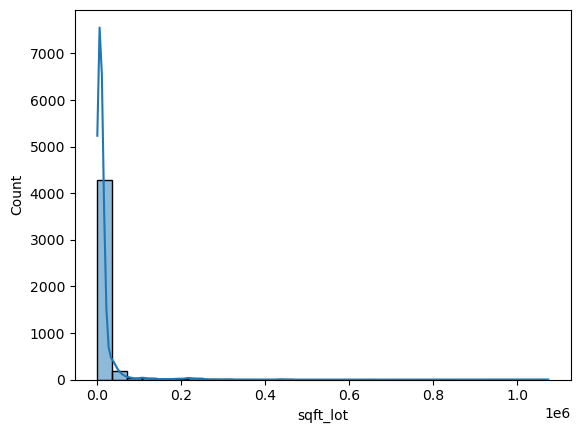

In [26]:
sns.histplot(data=dataF, x='sqft_lot', bins=30, kde=True)

<Axes: xlabel='sqft_basement', ylabel='Count'>

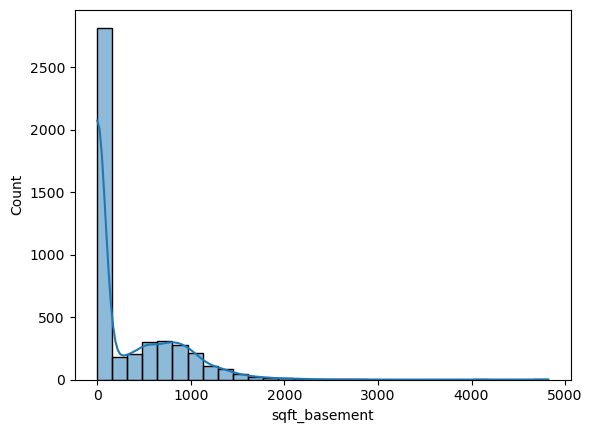

In [27]:
sns.histplot(data=dataF, x='sqft_basement', bins=30, kde=True)

<Axes: xlabel='sqft_above', ylabel='Count'>

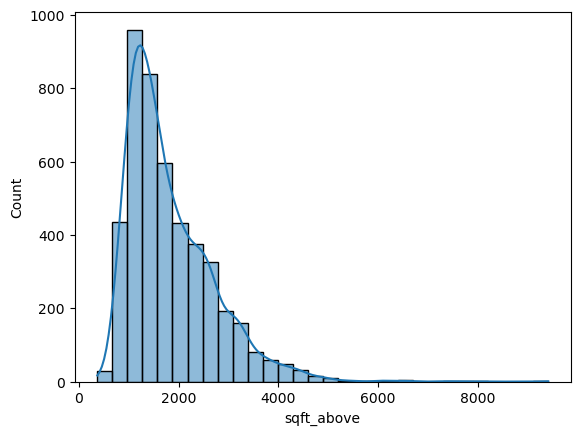

In [28]:
sns.histplot(data=dataF, x='sqft_above', bins=30, kde=True)

In [29]:
dataF.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

In [30]:
#Nombre de prix au dessus de 8e+04 :"
print("Nombre de prix trop bas :")
dataF[(dataF['price']<8e+04)].shape[0]

Nombre de prix trop bas :


50

In [31]:
dataF.drop(dataF[dataF['price']<8e+04].index, inplace=True)

In [32]:
#Vérification du drop :
dataF[(dataF['price']<8e+04)].shape[0]

0

In [37]:
Q1 = dataF['price'].quantile(0.25)
Q3 = dataF['price'].quantile(0.75)
seuil_outlier = Q3 + 2 *(Q3 -Q1)

In [46]:
nb_outliers = (dataF['price'] > seuil_outlier).sum()
print(f"Nombre d'outlier : {nb_outliers}") 

Nombre d'outlier : 163


<Axes: xlabel='price', ylabel='Count'>

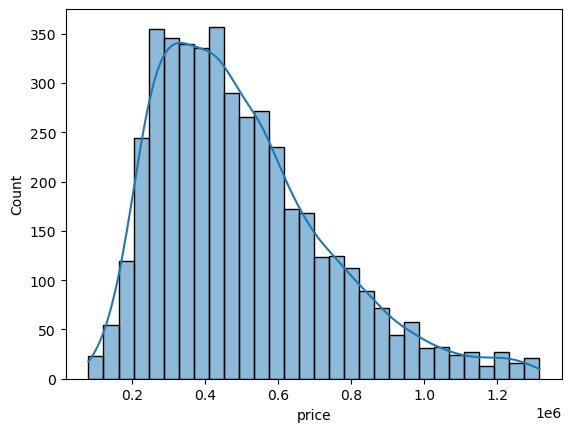

In [49]:
dataF.drop(dataF[dataF['price']>seuil_outlier].index, inplace=True)
sns.histplot(data=dataF, x='price', bins=30, kde=True)

<Axes: xlabel='price', ylabel='Count'>

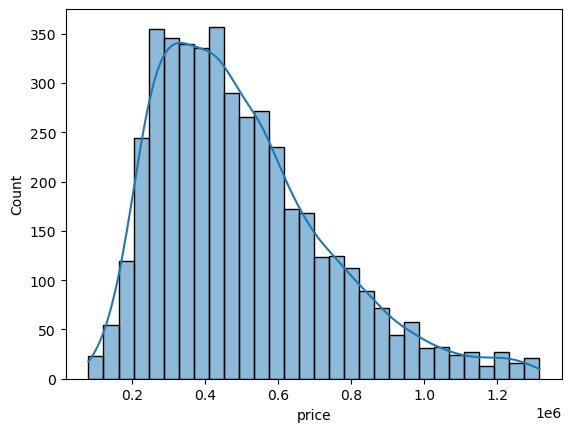

In [55]:
#Découpage des bacs
bacs = pd.cut(dataF['price'], bins=50)
#Comptage
nb_bacs = bacs.value_counts()

In [63]:
df_bacs = pd.DataFrame({
    'intervalle': nb_bacs.index,
    'nb_values' : nb_bacs.values
})

df_bacs_idx = df_bacs.sort_index()

In [64]:
print("=== DISTRIBUTION DES PRIX DANS 50 BACS ===")
print(f"Nombre total d'observations : {len(dataF)}")
print(f"Nombre de bacs créés : {len(df_bacs)}")
print("\nDétail des bacs (triés par intervalle) :")
print(df_bacs_idx.to_string(index=False))

=== DISTRIBUTION DES PRIX DANS 50 BACS ===
Nombre total d'observations : 4387
Nombre de bacs créés : 50

Détail des bacs (triés par intervalle) :
            intervalle  nb_values
  (425800.0, 450500.0]        225
  (327000.0, 351700.0]        223
  (277600.0, 302300.0]        212
  (228200.0, 252900.0]        211
  (302300.0, 327000.0]        206
  (376400.0, 401100.0]        204
  (252900.0, 277600.0]        196
  (401100.0, 425800.0]        191
  (524600.0, 549300.0]        189
  (351700.0, 376400.0]        186
  (450500.0, 475200.0]        182
  (475200.0, 499900.0]        158
  (549300.0, 574000.0]        157
  (499900.0, 524600.0]        142
  (598700.0, 623400.0]        138
  (574000.0, 598700.0]        128
  (203500.0, 228200.0]        122
  (648100.0, 672800.0]        116
  (623400.0, 648100.0]        100
  (672800.0, 697500.0]         92
  (722200.0, 746900.0]         88
  (746900.0, 771600.0]         78
  (178800.0, 203500.0]         78
  (796300.0, 821000.0]         69
  (6